In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import os
from scipy.optimize import curve_fit
from processing import filter_region, sort_avg_arr, sort_within_arr
from visualizations import lineplots_4x4
from datetime import datetime

# load prediction arrays, create array objects

In [2]:
folder_path = 'predictions/8-27-2025/'

In [3]:
folders = [folder for folder in os.listdir(folder_path)]
print('len of folders: ', len(folders))

len of folders:  110


In [4]:
test_sum = np.load(f'{folder_path}image0/sum_arr_image0.npy')
print('test_sum shape: ', test_sum.shape)

test_sum shape:  (1, 100, 7493)


In [5]:
def load_arrs(arr_type: str):
    if arr_type not in ['sum', 'mean', 'var', 'label']: raise ValueError ('---Insert "sum" or "mean" "var" or "label" as input---')
    return_arr = np.empty((110, 100, 7493)) if arr_type == 'sum' else np.empty((110, 7493))
    for arr_index in range(110):
        arr_temp = np.load(f'{folder_path}image{arr_index}/{arr_type}_arr_image{arr_index}.npy')
        return_arr[arr_index] = arr_temp
    return return_arr

In [6]:
sum_arr = load_arrs('sum')
mean_arr = load_arrs('mean')
var_arr = load_arrs('var')
label_arr = load_arrs('label')

In [7]:
print(f'sum shape: {sum_arr.shape}; mean shape: {mean_arr.shape}; var shape: {var_arr.shape}')

sum shape: (110, 100, 7493); mean shape: (110, 7493); var shape: (110, 7493)


In [8]:
np.unique(mean_arr == var_arr, return_counts = True) # ensure we are returning different arrays

(array([False]), array([824230]))

# get mean and var arrays from V1
filtering done as well

In [9]:
mean_v1 = filter_region(1, label_arr, mean_arr)
var_v1 = filter_region(1, label_arr, var_arr)

In [10]:
print(f'mean shape: {mean_v1.shape}, var shape: {var_v1.shape}')

mean shape: (110, 5312), var shape: (110, 5312)


In [11]:
mean_masked = np.where(mean_v1 > 200, np.nan, mean_v1)

In [12]:
mean_masked[0]

array([4.48253631, 2.40415138, 2.1741385 , ..., 3.46549727, 3.72360299,
       1.8011298 ])

In [13]:
var_masked = np.where(np.isnan(mean_masked), np.nan, var_v1)

In [14]:
var_masked

array([[0.08063027, 0.01644628, 0.02091719, ..., 0.02843449, 0.04020991,
        0.00977191],
       [0.07147933, 0.01843665, 0.02754832, ..., 0.03141268, 0.04010393,
        0.00822013],
       [0.08131231, 0.01864596, 0.02440153, ..., 0.02993036, 0.03761377,
        0.01028123],
       ...,
       [0.03619199, 0.06720968, 0.59309386, ..., 0.09813279, 0.5388874 ,
        0.12088601],
       [0.28648292, 0.00654168, 0.02622433, ..., 0.31492221, 0.57116872,
        0.03218335],
       [0.40654122, 0.00695528, 0.03502693, ..., 0.071912  , 0.10385039,
        0.03268105]])

In [15]:
print(f'# of mean nans: {np.isnan(mean_masked).sum()}; # of var nans: {np.isnan(var_masked).sum()}')

# of mean nans: 255; # of var nans: 255


# plots

In [19]:
neuron = 500
test_x = mean_masked[..., neuron]
test_y = var_masked[..., neuron]
print(test_x.shape)
print(test_y.shape)

(110,)
(110,)


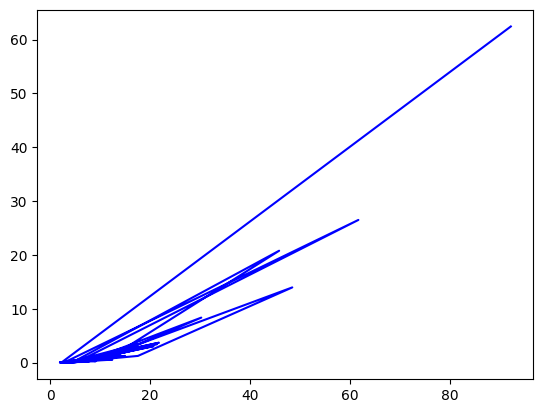

In [20]:
plt.plot(test_x[:10], test_y[:10], color = 'gray', linestyle = '--')
plt.plot(test_x[10:], test_y[10:], color = 'blue')
plt.show()

In [21]:
# get 16 random neurons here
neurons = np.random.randint(0, mean_v1.shape[1], 16)
neurons

array([3063, 2597, 3740, 1885, 2215, 2217, 3470, 1499, 1490, 3732, 5086,
       2692, 2445, 3507, 3135,  989], dtype=int32)

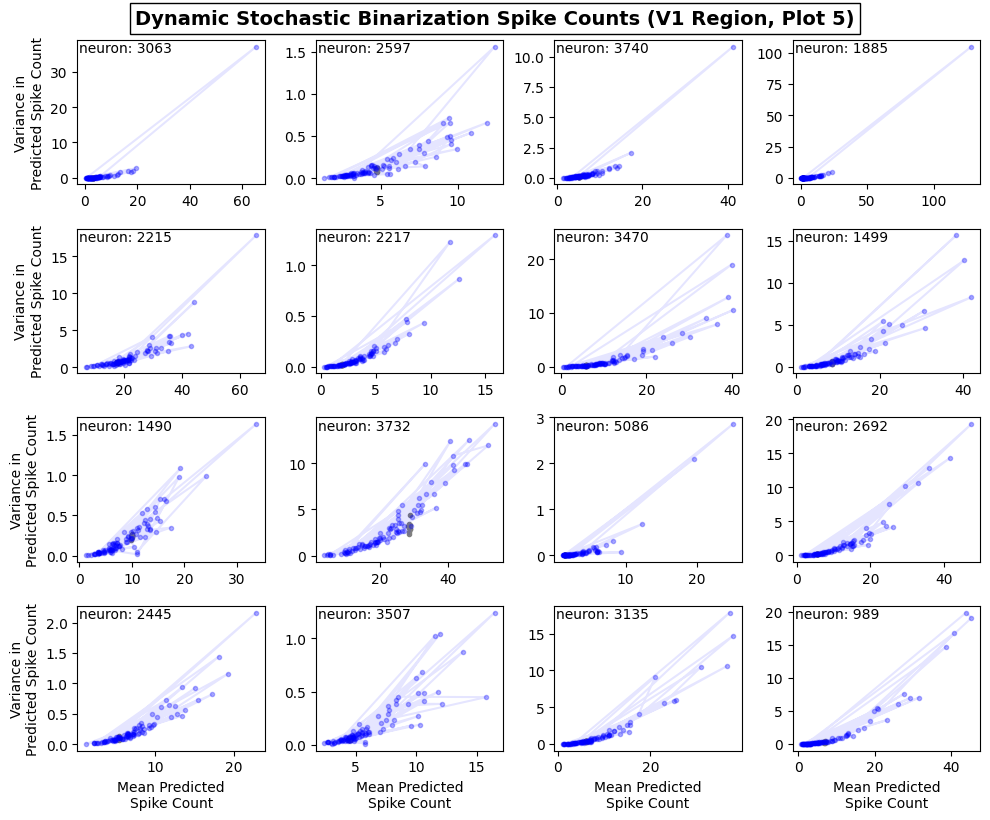

In [22]:
lineplots_4x4('Dynamic Stochastic Binarization Spike Counts (V1 Region, Plot 5)', neurons = neurons, mean_masked = mean_masked, var_masked = var_masked, savefig = False)

# sort ascending/descending

In [23]:
mean_masked.shape

(110, 5312)

In [24]:
np.mean(mean_masked, axis = 1).shape

(110,)

In [25]:
indices_sorted = sort_avg_arr(mean_masked, ascending = False)
indices_sorted.shape

(110,)

In [26]:
# sort both mean and var arrays based on avg value from mean
mean_sorted = mean_masked[indices_sorted]
var_sorted = var_masked[indices_sorted]
mean_sorted.shape

(110, 5312)

In [27]:
test = 0
for row_index in range(mean_sorted.shape[0]):
    row = mean_sorted[row_index]
    print(f'{test}, {np.nanmean(row):.4f}')
    test+=1

0, 14.7529
1, 13.3137
2, 11.3650
3, 11.2878
4, 11.2198
5, 11.1856
6, 11.1358
7, 11.1068
8, 10.9993
9, 10.9878
10, 10.9400
11, 10.8483
12, 10.8072
13, 10.7804
14, 10.7615
15, 10.7082
16, 10.6946
17, 10.6783
18, 10.6762
19, 10.6010
20, 10.5638
21, 10.5488
22, 10.4999
23, 10.4244
24, 10.4139
25, 10.4024
26, 10.2910
27, 10.2894
28, 10.2235
29, 10.2189
30, 10.2189
31, 10.1517
32, 10.1431
33, 10.0677
34, 10.0028
35, 9.9787
36, 9.9185
37, 9.8863
38, 9.8569
39, 9.8421
40, 9.8016
41, 9.7315
42, 9.6915
43, 9.5238
44, 9.5069
45, 9.4882
46, 9.3908
47, 9.3843
48, 9.3459
49, 9.3063
50, 9.3063
51, 9.2848
52, 9.2597
53, 9.2422
54, 9.2232
55, 9.1916
56, 9.0801
57, 9.0456
58, 9.0171
59, 8.9975
60, 8.9419
61, 8.9002
62, 8.7867
63, 8.7386
64, 8.7337
65, 8.6830
66, 8.6521
67, 8.6188
68, 8.6050
69, 8.5812
70, 8.5746
71, 8.4998
72, 8.4859
73, 8.4765
74, 8.4412
75, 8.4053
76, 8.3912
77, 8.3682
78, 8.3236
79, 8.2791
80, 8.2688
81, 8.2675
82, 8.2223
83, 8.2161
84, 8.1675
85, 8.1399
86, 8.0793
87, 8.0791
88, 8.0

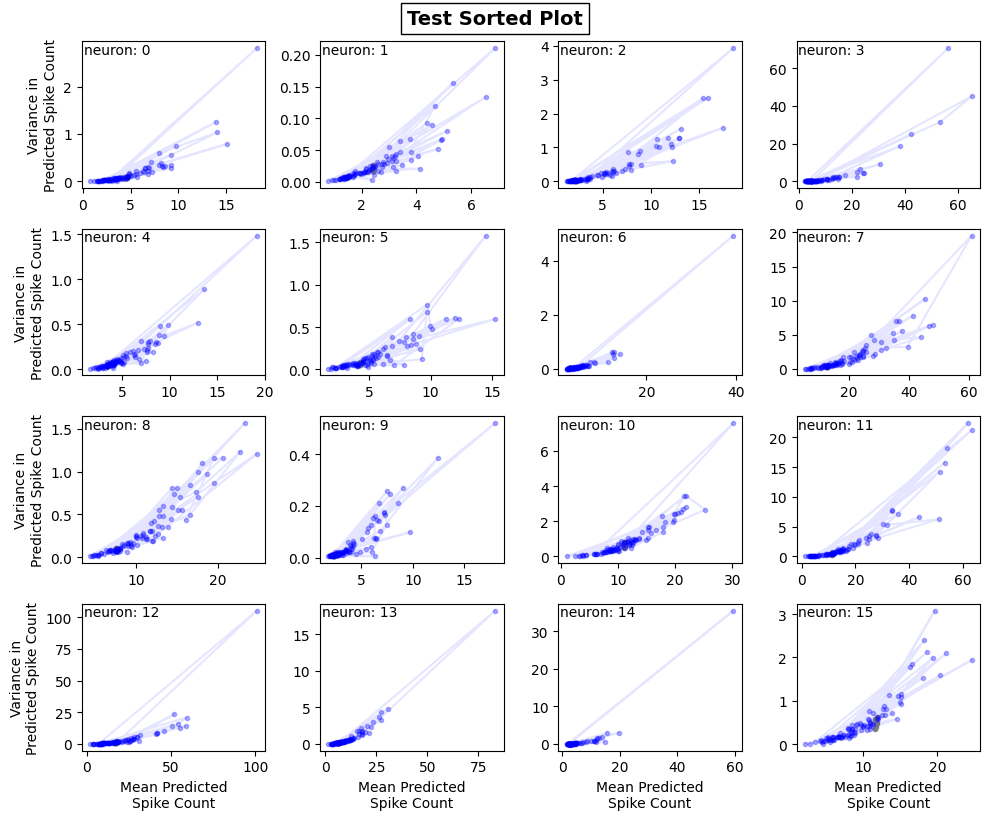

In [28]:
lineplots_4x4('Test Sorted Plot', neurons = [i for i in range(16)], mean_masked = mean_masked, var_masked = var_masked, savefig = False)

In [29]:
neuron = 58
test_neuron_mean = mean_masked[..., neuron]
test_neuron_var = var_masked[..., neuron]
test_neuron_mean.shape

(110,)

In [30]:
indices = sort_within_arr(test_neuron_mean)

In [31]:
test_neuron_mean = test_neuron_mean[indices]
test_neuron_var = test_neuron_var[indices]

In [32]:
test_neuron_mean

array([ 1.36118565,  1.40206765,  1.52611153,  1.63435053,  1.84144648,
        1.89281486,  1.92687643,  1.95148439,  1.98163611,  2.07971409,
        2.09243058,  2.15473148,  2.17790863,  2.26249593,  2.26575422,
        2.33908356,  2.4243632 ,  2.47006997,  2.5817903 ,  2.98209787,
        2.9863715 ,  3.0500001 ,  3.24612016,  3.28235424,  3.49112466,
        3.53691246,  3.62198842,  3.64512624,  3.77773921,  3.96875736,
        3.98245703,  4.03680215,  4.08094704,  4.09432437,  4.11655376,
        4.12528009,  4.17773989,  4.21870381,  4.24323443,  4.2487227 ,
        4.25004379,  4.26700319,  4.27320543,  4.27509768,  4.28185955,
        4.28526509,  4.28891385,  4.29302422,  4.30210389,  4.32567643,
        4.3526025 ,  4.42957079,  4.43147419,  4.43246734,  4.47429477,
        4.50936666,  4.54939431,  4.63759359,  4.67605702,  4.86282288,
        4.93438613,  4.9733816 ,  4.98679603,  5.07692926,  5.12446552,
        5.36523426,  5.39969533,  5.48440592,  5.48523032,  5.54

In [33]:
test_neuron_var

array([1.12240913e-03, 4.68023974e-03, 6.20109298e-03, 8.48937479e-03,
       4.33910606e-03, 7.52698710e-03, 7.92821010e-03, 1.56797545e-02,
       1.85827147e-02, 1.14644353e-02, 1.43396571e-02, 2.09627036e-02,
       1.79176577e-02, 2.22306341e-02, 1.74047848e-02, 2.58706225e-02,
       1.58565423e-02, 1.92103519e-02, 1.70054913e-02, 5.87867179e-02,
       2.08442264e-02, 3.31766379e-02, 4.33079249e-02, 5.64297705e-02,
       5.37049735e-02, 7.36671446e-02, 3.59314397e-02, 7.47346522e-02,
       4.45048267e-02, 8.15969415e-02, 6.27411169e-02, 1.33815551e-01,
       6.06697142e-02, 8.00414066e-02, 1.03017770e-01, 7.49134288e-02,
       1.02464134e-01, 1.08202243e-01, 6.33524452e-02, 6.51729001e-02,
       8.57333866e-02, 7.32436943e-02, 6.42850554e-02, 6.48511453e-02,
       6.84463041e-02, 7.37385393e-02, 6.57148355e-02, 6.11108168e-02,
       8.31174190e-02, 7.46046955e-02, 7.66114494e-02, 7.50855018e-02,
       9.47342146e-02, 9.11716894e-02, 1.13873989e-01, 9.67106919e-02,
      

In [34]:
for row_index in range(mean_masked.shape[0]):
    indices = sort_within_arr(mean_masked[row_index])
    mean_masked[row_index] = mean_masked[row_index][indices]
    var_masked[row_index] = var_masked[row_index][indices]


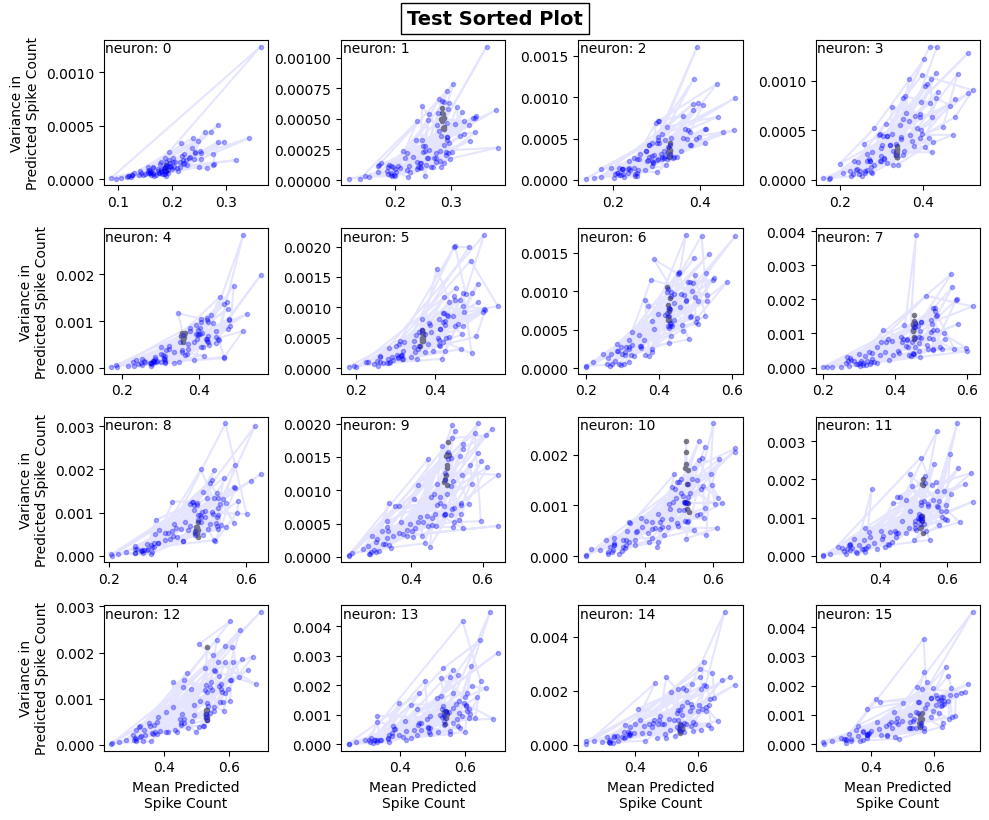

In [35]:
lineplots_4x4('Test Sorted Plot', neurons = [i for i in range(16)], mean_masked = mean_masked, var_masked = var_masked, savefig = False)

# plotting function

In [36]:
def smooth_func(x, m, b):
    """    
    Parameters
    ----------
    x : float or np.ndarray
        Input value(s) along the x-axis
    m : float
        Scaling parameter
    b : float
        Growth rate parameter
    
    Returns
    -------
    float or np.ndarray
        Function value(s) f(x)
    """
    return (m / b) * (np.log1p(np.exp(b * x)) - np.log(2) - (b * x) / 2)

In [37]:
neuron = 58
test_neuron_mean = mean_masked[..., neuron]
test_neuron_var = var_masked[..., neuron]
test_neuron_mean.shape

(110,)

In [38]:
indices = sort_within_arr(test_neuron_mean)

In [39]:
test_neuron_mean = test_neuron_mean[indices]
test_neuron_var = test_neuron_var[indices]

In [40]:
test_neuron_mean

array([0.35181312, 0.3840674 , 0.43070462, 0.45454116, 0.49431911,
       0.4944383 , 0.49660986, 0.50434736, 0.5166285 , 0.51978102,
       0.52091294, 0.52409402, 0.52616697, 0.53099842, 0.5314139 ,
       0.53195218, 0.5380877 , 0.54524795, 0.54622653, 0.54849025,
       0.55700335, 0.56281695, 0.57438093, 0.58881009, 0.59796946,
       0.60222666, 0.62726064, 0.65139305, 0.65282332, 0.65581983,
       0.66549143, 0.66924111, 0.67201344, 0.67666662, 0.68095718,
       0.6839433 , 0.68749664, 0.70369199, 0.71361861, 0.73125352,
       0.73470297, 0.73677449, 0.74172854, 0.74441924, 0.74946381,
       0.75047625, 0.75067501, 0.75189069, 0.77063465, 0.77245681,
       0.77868255, 0.78125339, 0.78273239, 0.78276545, 0.78502497,
       0.78519833, 0.78577113, 0.78628238, 0.78809447, 0.78809836,
       0.78900975, 0.78901985, 0.78993515, 0.7905739 , 0.79121453,
       0.79254815, 0.79347297, 0.79566792, 0.79771357, 0.80638416,
       0.81131907, 0.8132118 , 0.82064122, 0.82121028, 0.82488

In [41]:
test_neuron_var

array([1.57820981e-04, 1.57223268e-05, 3.04210530e-04, 3.84308963e-04,
       5.71252002e-04, 1.09290116e-03, 2.37545210e-04, 5.09219282e-04,
       1.24908373e-03, 1.98885054e-04, 1.10757064e-03, 5.10791265e-04,
       2.50621813e-04, 9.79301232e-04, 1.47706423e-03, 8.31518169e-04,
       6.07229028e-04, 3.92404585e-04, 5.61832341e-04, 1.59078369e-04,
       6.86530709e-04, 1.11194125e-03, 7.43835787e-04, 8.38738701e-04,
       9.96137293e-04, 1.31506266e-03, 8.74411546e-04, 1.99568718e-03,
       3.76018872e-04, 9.40969977e-04, 1.02212308e-03, 1.54472766e-03,
       3.88132822e-04, 1.23887283e-03, 1.77449768e-03, 1.52667853e-03,
       9.01556752e-04, 2.41824219e-03, 3.09527821e-03, 2.26744976e-03,
       3.94792425e-03, 3.97445183e-03, 2.08572036e-03, 2.63087492e-03,
       1.88132488e-03, 2.52871986e-03, 2.08713425e-03, 9.64340235e-04,
       1.12292123e-03, 6.45681248e-03, 2.70516761e-03, 3.28598289e-03,
       2.13681722e-03, 2.67915348e-03, 2.09940073e-03, 2.95383900e-03,
      

In [42]:
m = 1
b = 1
y_pred = smooth_func(test_neuron_mean, m, b)
y_pred

array([0.01539242, 0.01832625, 0.02301126, 0.02560665, 0.03023792,
       0.03025236, 0.030516  , 0.0314644 , 0.03299856, 0.03339808,
       0.03354209, 0.03394842, 0.03421447, 0.03483847, 0.03489238,
       0.03496229, 0.03576392, 0.0367105 , 0.0368408 , 0.03714305,
       0.03829038, 0.03908354, 0.04068446, 0.04272523, 0.04404548,
       0.04466566, 0.04839624, 0.0521271 , 0.05235234, 0.05282574,
       0.05436747, 0.05497084, 0.05541897, 0.05617499, 0.05687638,
       0.05736696, 0.05795331, 0.06066133, 0.06234988, 0.06540323,
       0.06600846, 0.06637318, 0.06724922, 0.06772727, 0.06862778,
       0.06880918, 0.06884482, 0.06906299, 0.07246739, 0.0728024 ,
       0.07395245, 0.07442978, 0.07470504, 0.0747112 , 0.07513264,
       0.07516502, 0.07527206, 0.07536765, 0.07570692, 0.07570765,
       0.07587855, 0.07588045, 0.07605227, 0.07617228, 0.07629273,
       0.07654377, 0.07671808, 0.07713251, 0.07751968, 0.07917067,
       0.0801175 , 0.08048203, 0.08192024, 0.08203088, 0.08274

In [43]:
params, covariance = curve_fit(smooth_func, test_neuron_mean, test_neuron_var)
print(f'fitted paramters: {params}\n covariance\n {covariance}')

fitted paramters: [0.90433151 0.03596076]
 covariance
 [[1461129.64845552  -58106.25633625]
 [ -58106.25633625    2310.77169235]]


In [44]:
m_fitted, b_fitted = params

In [45]:
y_fitted = smooth_func(test_neuron_mean, m_fitted, b_fitted)

# final lineplot function

In [46]:
def smooth_func(x, m, b): # used for regression in lineplots_4x4

    """    
    Parameters
    ----------
    x : float or np.ndarray
        Input value(s) along the x-axis
    m : float
        Scaling parameter
    b : float
        Growth rate parameter
    
    Returns
    -------
    float or np.ndarray
        Function value(s) f(x)
    """
    return (m / b) * (np.log1p(np.exp(b * x)) - np.log(2) - (b * x) / 2)


def lineplots_4x4(main_title, neurons, mean_masked, var_masked, savefig = False, sort_arrays = True, sort_arrays_ascending = False,
                  sort_within_array = True, sort_within_arr_ascending = True):
    # neurons is not for the actual neurons
    """
    ADD DOCS
    note that here we sort neurons by avg firing rate and then label, so neuron label 0 indicates neuron with highest avg firing rate
    """
    if sort_arrays:
        indices_sorted = sort_avg_arr(mean_masked, ascending = sort_arrays_ascending)
        mean_masked = mean_masked[..., indices_sorted]
        var_masked = var_masked[..., indices_sorted]
        print('array sorted')

    if sort_within_array:
        for neuron_index in range(mean_masked.shape[1]):
            indices_within_arr = sort_within_arr(var_masked[neuron_index], ascending = sort_within_arr_ascending)
            mean_masked[..., neuron_index] = mean_masked[..., neuron_index][indices_within_arr]
            var_masked[..., neuron_index] = var_masked[..., neuron_index][indices_within_arr]
        print('sorted within array')


    fig, axes = plt.subplots(4, 4, figsize=(10, 8), sharex=False, sharey=False)
    fig.text(0.5, 1.02, main_title, ha='center', va='top', fontsize=14, fontweight = 'bold', bbox=dict(facecolor='white'))

    for id, neuron in enumerate(neurons):
        i, j = divmod(id, 4)
        ax = axes[i, j]
        ax.text(0.01, 0.99, f'neuron: {neuron}', verticalalignment = 'top', horizontalalignment = 'left', 
                transform = ax.transAxes)
        ax.scatter(mean_masked[..., neuron][:10], var_masked[..., neuron][:10], color = 'gray', marker = '^')
        ax.scatter(mean_masked[..., neuron][10:], var_masked[..., neuron][10:], color = 'b', alpha = 0.3, marker = '.')
        ax.plot(mean_masked[..., neuron], var_masked[..., neuron], color = 'b', alpha = 0.1)

        if i == 3: ax.set_xlabel('Mean Predicted\nSpike Count')
        if j == 0: ax.set_ylabel('Variance in\nPredicted Spike Count')

        # plot regression
        x = mean_masked[..., neuron]
        y = var_masked[..., neuron]
        params, covariance = curve_fit(smooth_func, x, y)
        m_fitted, b_fitted = params
        y_fitted = smooth_func(x, m_fitted, b_fitted)
        ax.plot(x, y_fitted, color = 'r', alpha = 0.5, label = 'regression')


    plt.tight_layout()
    if savefig: 
        try:
            date = datetime.now()
            file_date = f'({str(date.month)}-{str(date.day)}-{str(date.year)})'
            path_name = f'{main_title}_{file_date}.pdf'
            plt.savefig(os.path.join(os.getcwd(), f'plots//({str(date.month)}-{str(date.day)}-{str(date.year)})', path_name), 
                        bbox_inches = 'tight', pad_inches = 0.3)
        except FileNotFoundError:
            os.makedirs(f'plots//({str(date.month)}-{str(date.day)}-{str(date.year)})', exist_ok = True)
            plt.savefig(os.path.join(os.getcwd(), f'plots//({str(date.month)}-{str(date.day)}-{str(date.year)})', path_name),
                        bbox_inches = 'tight', pad_inches = 0.3)
            plt.close()
    else: 
        plt.show()

array sorted
sorted within array


IndexError: index 5000 is out of bounds for axis 1 with size 110

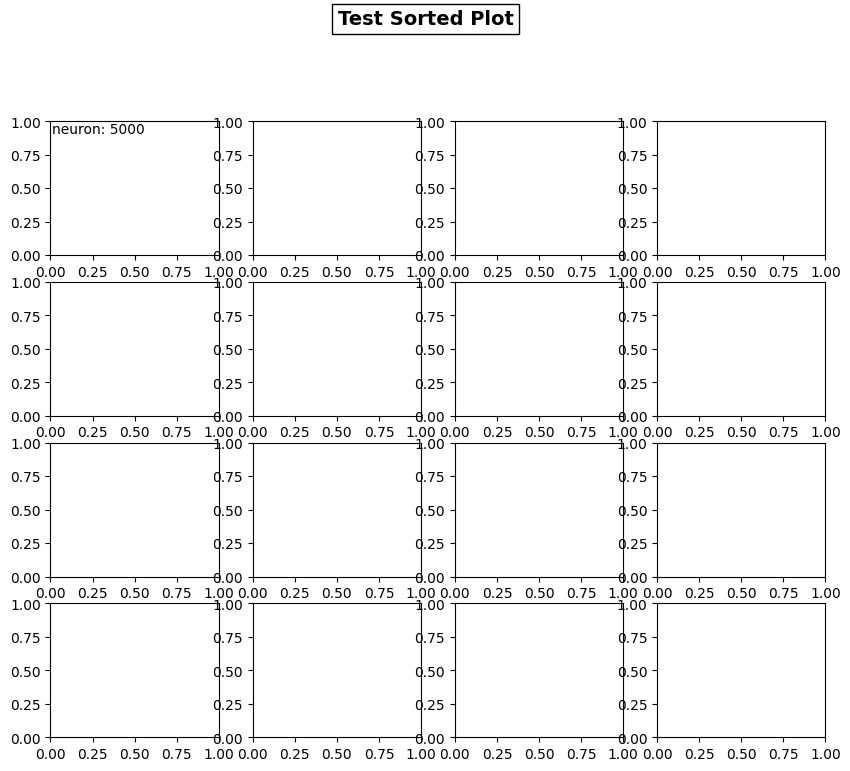

In [47]:
lineplots_4x4('Test Sorted Plot', neurons = [i for i in range(5000, 5016)], mean_masked = mean_masked, var_masked = var_masked, 
              sort_arrays = True, sort_within_array = True)